In [1]:
import numpy as np

from core.loss import MAE, MSE
from core.optim import SGD
from utils.plots import plot_predictions
from models.LinearRegression import LinearRegression

In [2]:
# Create some data
weight = 0.7
bias = 0.7
start = 0
end = 1
step = 0.01

np.random.seed(42)

# Create data
X = np.expand_dims(np.arange(start, end, step), axis=1)
Y = weight * X + bias

print(len(X))
X[:5], Y[:5]

100


(array([[0.  ],
        [0.01],
        [0.02],
        [0.03],
        [0.04]]),
 array([[0.7  ],
        [0.707],
        [0.714],
        [0.721],
        [0.728]]))

In [3]:
train_split = int(0.8 * len(X))
X_train, y_train, X_test, y_test = X[:train_split], Y[:train_split], X[train_split:], Y[train_split:]

len(X_train), len(X_test),len(y_train), len(y_test)

(80, 20, 80, 20)

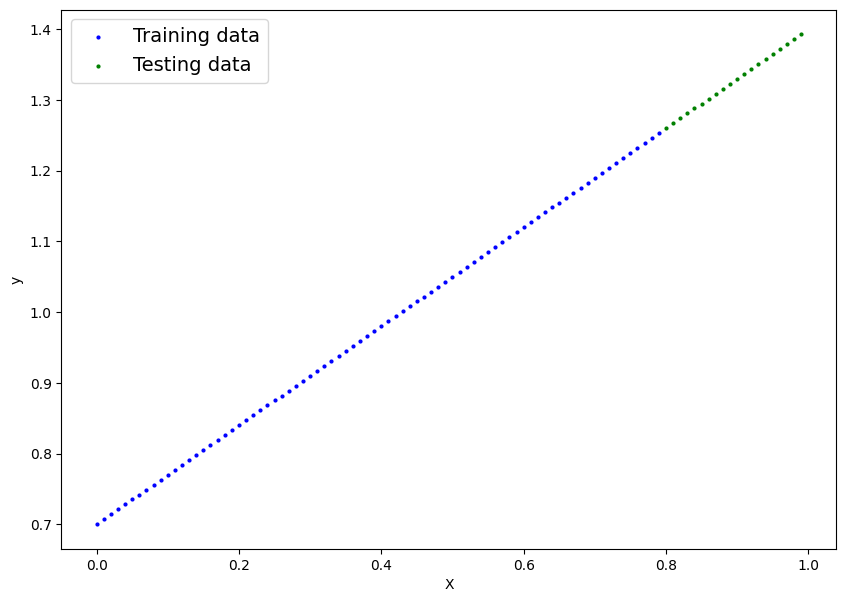

In [4]:
plot_predictions(X_train, y_train, X_test, y_test)

In [5]:
model = LinearRegression()

model

In [28]:
loss_fn = MSE()
optimizer = SGD(model, lr=0.1)

In [29]:
np.random.seed(42)

epochs = 5000

for epoch in range(epochs):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss_fn.backward(model)
    optimizer.step()
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred, y_test)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.11232 | Test loss: 0.00606
Epoch: 10 | Train Loss: 0.01059 | Test loss: 0.00234
Epoch: 20 | Train Loss: 0.00097 | Test loss: 0.00034
Epoch: 30 | Train Loss: 0.00009 | Test loss: 0.00004
Epoch: 40 | Train Loss: 0.00001 | Test loss: 0.00000
Epoch: 50 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 60 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 70 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 80 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 90 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 100 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 110 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 120 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 130 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 140 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 150 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 160 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 170 | Train Loss: 0.00000 | Test loss: 0.00000
Epoch: 180 | Train Loss: 0.00000 | Test

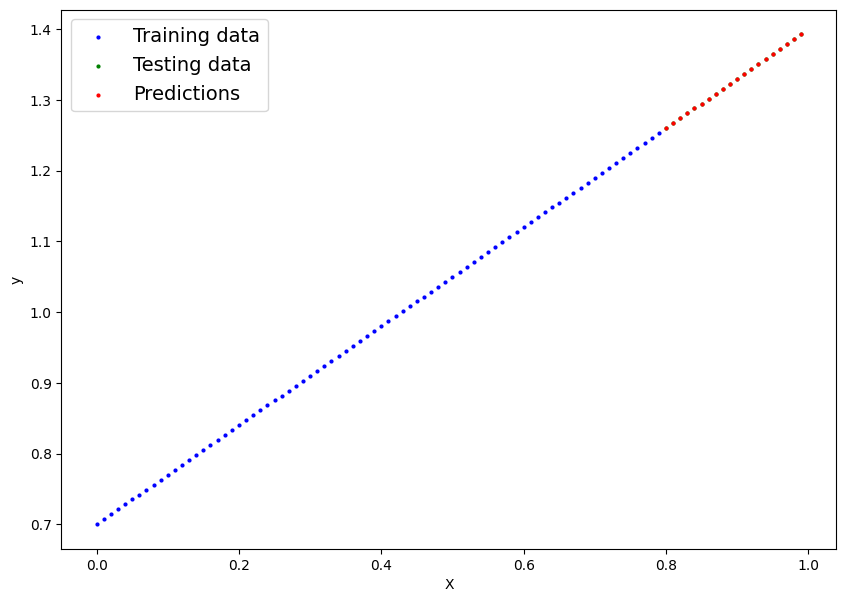

In [30]:
y_preds = model(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [31]:
model.parameters()

[(array([[ 0.30674168,  1.39825257,  0.51697267,  0.93038321, -0.99817761,
          -0.87907694, -1.84515501,  1.74604272,  0.81726769,  1.39806012]]),
  array([[ 1.95510449e-18,  1.13688289e-17,  4.34898089e-18,
           6.97521542e-18, -8.06142169e-18, -7.09105671e-18,
          -1.45839522e-17,  1.36319960e-17,  6.34276920e-18,
           1.07185217e-17]])),
 (array([[-0.17192469, -0.33056172, -0.0948699 , -0.32563976,  0.23835342,
           0.20290794,  0.51225488, -0.51449591, -0.25688221, -0.44468492]]),
  array([[ 5.43658058e-18,  3.16134277e-17,  1.20932591e-17,
           1.93960584e-17, -2.24164841e-17, -1.97181795e-17,
          -4.05537565e-17,  3.79066414e-17,  1.76374082e-17,
           2.98051113e-17]])),
 (array([[-0.02137508, -0.04248   , -0.12105775, -0.00870615,  0.05328338,
           0.03666307, -0.03715334,  0.02813935, -0.02662126, -0.05612418],
         [-0.14050603, -0.14241472, -0.21674594,  0.19659862,  0.34699348,
           0.03973687, -0.07380814, -0.0